In [1]:
import numpy as np
import random as rd
import pandas as pd
import math
import secrets as st
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import itertools
from scipy.spatial import cKDTree
import random

In [99]:
time_step = 1
T = 100
def initialize() :
    global N, L, positions, directions, order_parameters
    positions = np.zeros((N, T, 2))
    directions = np.zeros((N, T))
    positions[:, 0, :] = np.random.uniform(0, L, (N, 2))
    directions[:, 0] = np.random.uniform(0, 2*np.pi, (N, ))

def update(t) :
    global R, v, etta

    #positions update
    dirs_vector = np.array(np.column_stack([
        np.cos(directions[:, t-1]),
        np.sin(directions[:, t-1])
    ]))
    positions[:, t, :] = (positions[:, t-1, :] + dirs_vector*v*time_step) % L

    #neighbors
    tree = cKDTree(positions[:, t-1, :], boxsize = L)
    neighbors_lists = tree.query_ball_tree(tree, R)

    #direction update
    for i in range(len(neighbors_lists)) :
        x_dirs = np.cos(directions[neighbors_lists[i], t-1])
        y_dirs = np.sin(directions[neighbors_lists[i], t-1])
        directions[i, t] = (np.arctan2(np.mean(y_dirs), np.mean(x_dirs))
                            + random.uniform(-etta/2, etta/2))

In [93]:
v_vector = np.column_stack([
    np.cos(directions[:, 2-1]),
    np.sin(directions[:, 2-1])
    ])
v_vector

array([[ 0.89838757,  0.43920356],
       [-0.4100803 , -0.91204942],
       [ 0.99993697, -0.01122707],
       [-0.09201437, -0.99575768],
       [-0.8268358 , -0.56244338],
       [ 0.38134187, -0.92443408],
       [ 0.31317096, -0.94969677],
       [-0.86524696,  0.50134589],
       [ 0.69878143,  0.71533525],
       [-0.93913158, -0.34355768],
       [ 0.1699941 ,  0.98544508],
       [-0.8819536 ,  0.47133623],
       [-0.17112509, -0.98524931],
       [ 0.99823845, -0.05932952],
       [ 0.75125363,  0.66001362],
       [-0.92540629,  0.37897651],
       [ 0.69737153,  0.71670981],
       [ 0.32030825, -0.94731337],
       [-0.95046633,  0.31082754],
       [-0.12146101, -0.9925962 ],
       [-0.97255523, -0.23267212],
       [ 0.15823485,  0.98740151],
       [-0.60677895,  0.79487063],
       [ 0.89900802,  0.43793217],
       [-0.69012783, -0.72368749],
       [ 0.32882852, -0.94438965],
       [-0.54275473, -0.83989124],
       [-0.70266117, -0.71152461],
       [ 0.94953532,

In [94]:
def run_simulation() :
  global directions
  initialize()
  for t in range(1, 100) :
    update(t)

In [95]:
def animation() :
    global T
    fig, ax = plt.subplots()
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    x_positions = positions[:, :, 0]
    y_positions = positions[:, :, 1]
    quiver = ax.quiver(x_positions[0], y_positions[0],
                        np.cos(directions[0]), np.sin(directions[0]),
              color='blue', width=0.005)
    individual_particle = random.randint(0, N-1)
    individual_arrow = ax.quiver([x_positions[0][individual_particle]],
                                [y_positions[0][individual_particle]],
                                [np.cos(directions[0][individual_particle])],
                                [np.sin(directions[0][individual_particle])],
                                color='red', width=0.005)
    def update0(frame):
      quiver.set_offsets(np.column_stack((x_positions[frame], y_positions[frame])))
      quiver.set_UVC(np.cos(directions[frame]), np.sin(directions[frame]))
      individual_arrow.set_offsets(np.column_stack((
                [x_positions[frame][individual_particle]],
                [y_positions[frame][individual_particle]])))
      individual_arrow.set_UVC([np.cos(directions[frame][individual_particle])],
                               [np.sin(directions[frame][individual_particle])])
      return quiver, individual_arrow,
    ani = FuncAnimation(fig, update0, frames=T, interval=300, blit=True)
    ax.set_title(f"N={N}   L={L}   v={v}   R={R}   etta={etta}   T={T}")
    ani.save("sample.gif")

In [96]:
N = 100
L = 5
R = 0.3
etta = 0.2
v = 0.03

In [97]:
run_simulation()

MovieWriter ffmpeg unavailable; using Pillow instead.


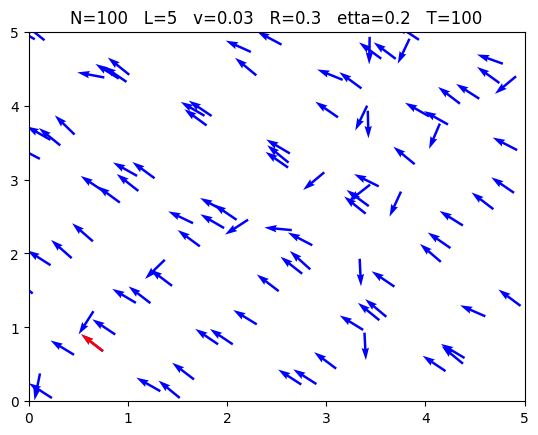

In [98]:
animation()